In [45]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import string 
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to C:\Users\AHMAD ADAM
[nltk_data]     HAKIMI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
#EDA

data = pd.read_csv('spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [47]:
data.shape

(5171, 4)

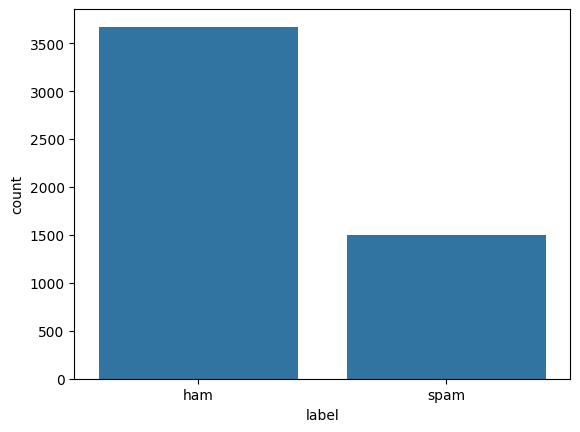

In [48]:
# What is ham ? 
# Ham refers to legitimate, non-spam emails
# What is spam ?
# Spam refers to unsolicited, often irrelevant or inappropriate emails that are sent in bulk to a large number of recipients.
sns.countplot(x='label', data=data)
plt.show()

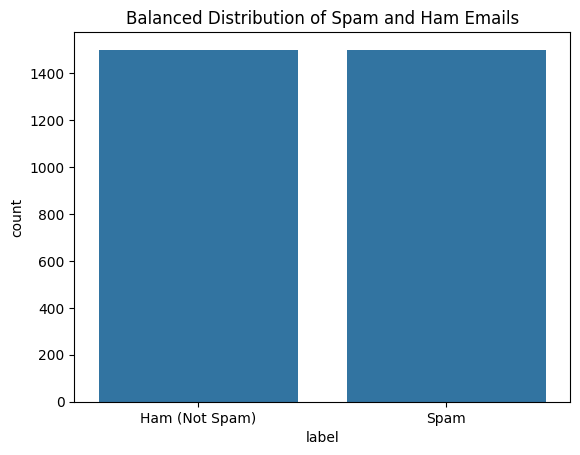

In [49]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match the number of spam email
# Why we do this?
# Because the dataset is imbalanced, and we want to create a balanced dataset for training our model. 
# By downsampling the ham emails, we can ensure that the model does not become biased towards the majority class (ham) and can learn to identify spam emails effectively.
# So, does that means that we just remove the ham emails that are not selected in the downsampling process?
# Yes, the ham emails that are not selected in the downsampling process will be removed from the dataset, and only the selected ham emails will be used for training the model.
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
# Explain about this LOC
# pd.concat() is used to concatenate the balanced ham messages and spam messages
# Concatenation in malay: Penggabungan
# reset_index(drop=True) is used to reset the index of the combined dataframe
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
# xticks is used to set the x-axis ticks, and labels is used to set the x-axis labels
# But i don see any ticks on the graph, why?
# The ticks may not be visible because the x-axis labels are long and may overlap with each other. You can try increasing the figure size or rotating the x-axis labels to make them more readable.
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0,1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

In [50]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [51]:
# I know that this function is used to remove punctuation but how it can be done?
# The remove_punctuations function uses the str.maketrans() method to create a translation table that maps each punctuation character to None. 
# Then, it uses the translate() method to remove all punctuation characters from the input text based on the translation table.
# How str.maketrans() works?
# The str.maketrans() method takes three arguments: x, y, and z.
# x is a string containing characters to be replaced, y is a string containing characters to replace with, and z is a string containing characters to be deleted.
# In this case, we are only using the z argument to specify the punctuation characters that we want to remove from the text. The x and y arguments are left empty since we are not replacing any characters.
# So, the str.maketrans('', '', punctuations_list) creates a translation table that maps each punctuation character in the punctuations_list to None, which means that when we call text.translate(temp), it will remove all punctuation characters from the text.
# The function call is '' is an empty string, which means that we are not replacing any characters, and the second '' is also an empty string, which means that we are not replacing any characters with anything else. The third argument is the punctuations_list, 
# which contains all the punctuation characters that we want to remove from the text.
# Can I change the empty string to . or any other character?
# Yes, you can change the empty string to any character you want. For example, if you want to replace punctuation characters with a space, you can use ' ' instead of '' in the str.maketrans() method.
# What should be sample output before and after applying this function?
# Before applying the function, the text may contain punctuation characters such as "Hello, how are you?".
# After applying the function, the text would be "Hello how are you" with all punctuation characters removed.
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)


balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [52]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')
    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)
    
    output = " ".join(imp_words)

    return output

balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


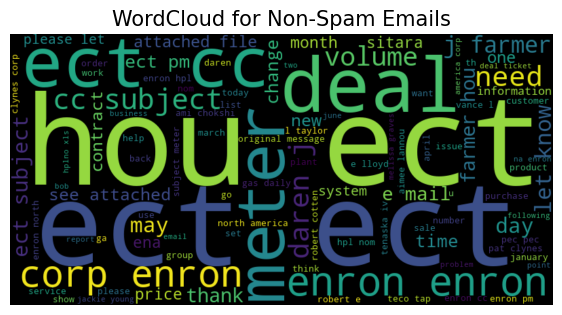

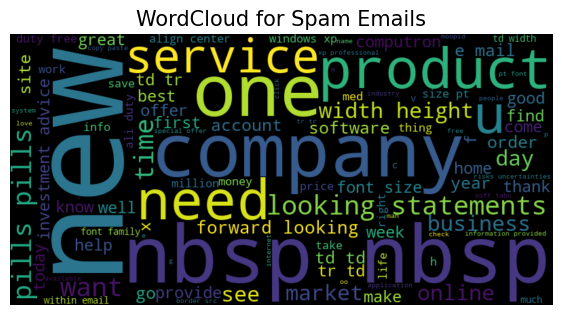

In [53]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)

    plt.figure(figsize=(7,7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')


In [54]:
# Tokenization and Padding
train_X, test_X, train_y, test_y = train_test_split(balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_y = (train_y =='spam').astype(int)
test_y = (test_y =='spam').astype(int)


In [55]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_y,
    validation_data=(test_sequences, test_y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5742 - loss: 0.6775 - val_accuracy: 0.6600 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8832 - loss: 0.4010 - val_accuracy: 0.9317 - val_loss: 0.2556 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9116 - loss: 0.2905 - val_accuracy: 0.8200 - val_loss: 0.4676 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8549 - loss: 0.3890 - val_accuracy: 0.9250 - val_loss: 0.2682 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9241 - loss: 0.2571 - val_accuracy: 0.9483 - val_loss: 0.2157 - learning_rate: 5.0000e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9550 - loss: 0.1854 - val_accuracy: 0.9583 - val_loss: 0.1737 - learning_rate: 5.0000e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9612 - loss: 0.1593 -

In [57]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

12/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9671 - loss: 0.1567 

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9583 - loss: 0.1737
Test Loss : 0.173665851354599
Test Accuracy : 0.9583333134651184


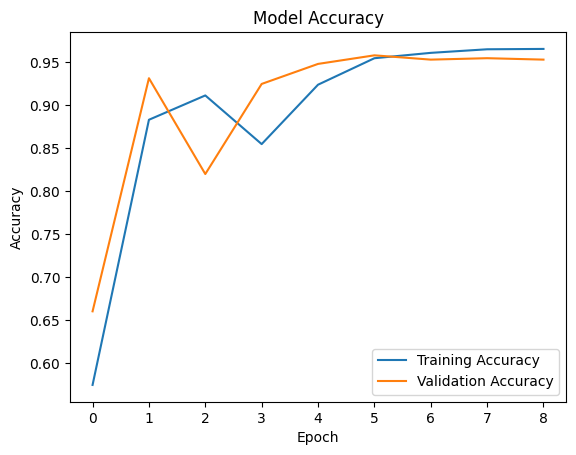

In [58]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()